# Step 6 - CNN Classification Model

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
import numpy as np
from PIL import Image
from torchsummary import summary

data = np.load('images_labels_rrr.npz')
images = data['images']
labels = data['labels']

In [ ]:
# Keep uint8 -> convert to float only inside transform
print("Data shape:", images.shape, "Labels:", np.unique(labels, return_counts=True))

class ImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx])   # still uint8 RGB
        label = int(self.labels[idx])

        if self.transform:
            img = self.transform(img)

        return img, label

# Transforms
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])
# Slight augmentation for training only — reduces overfitting, keeps train/val close
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

Data shape: (3478, 224, 224, 3) Labels: (array([0, 1], dtype=uint8), array([1656, 1822]))


In [ ]:
# Split & Loaders
X_train, X_val, y_train, y_val = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

train_dataset = ImageDataset(X_train, y_train, transform_train)
val_dataset   = ImageDataset(X_val, y_val, transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
# Custom 5-Layer CNN (regularized to avoid overfitting)
class SmallCNN(nn.Module):
    def __init__(self, num_classes=2):
        super(SmallCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),  # 224×224×32
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(0.1),
            nn.MaxPool2d(2),                                       # 112×112

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(0.15),
            nn.MaxPool2d(2),                                       # 56×56

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(0.2),
            nn.MaxPool2d(2),                                       # 28×28

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),                                       # 14×14

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))                            # 1×1×512
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.6),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Train (with early stopping + stronger regularization)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SmallCNN(num_classes=2).to(device)

print("\nCNN Model Summary\n")
summary(model, (3, 224, 224))

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-2)  # stronger L2

num_epochs = 50
patience = 6
best_val_loss = float("inf")
epochs_no_improve = 0
best_state = None

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(out, 1)
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation (loss + acc)
    model.eval()
    val_correct, val_total = 0, 0
    val_loss_sum = 0.0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            out = model(imgs)
            loss = criterion(out, lbls)
            val_loss_sum += loss.item() * imgs.size(0)
            _, preds = torch.max(out, 1)
            val_correct += (preds == lbls).sum().item()
            val_total += lbls.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total
    print(f"Epoch [{epoch+1}/{num_epochs}]  Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}")

    # Early stopping: stop when val loss doesn't improve for `patience` epochs
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} (no val loss improvement for {patience} epochs).")
            if best_state is not None:
                model.load_state_dict(best_state)
                model.to(device)
                print("Restored best model (lowest val loss).")
            break

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

if best_state is not None and epochs_no_improve < patience:
    # Finished all epochs; use best checkpoint
    model.load_state_dict(best_state)
    model.to(device)
    print("Loaded best model by val loss.")


CNN Model Summary

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
       BatchNorm2d-2         [-1, 32, 224, 224]              64
              ReLU-3         [-1, 32, 224, 224]               0
         Dropout2d-4         [-1, 32, 224, 224]               0
         MaxPool2d-5         [-1, 32, 112, 112]               0
            Conv2d-6         [-1, 64, 112, 112]          18,496
       BatchNorm2d-7         [-1, 64, 112, 112]             128
              ReLU-8         [-1, 64, 112, 112]               0
         Dropout2d-9         [-1, 64, 112, 112]               0
        MaxPool2d-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 128, 56, 56]          73,856
      BatchNorm2d-12          [-1, 128, 56, 56]             256
             ReLU-13          [-1, 128, 56, 56]               0
        Dropout2d-1

# Results Visualisation

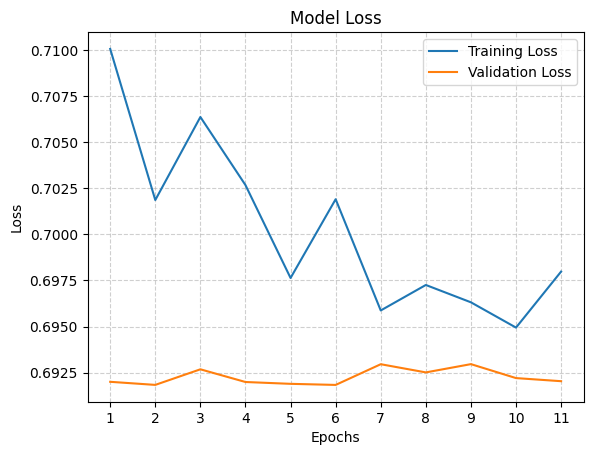

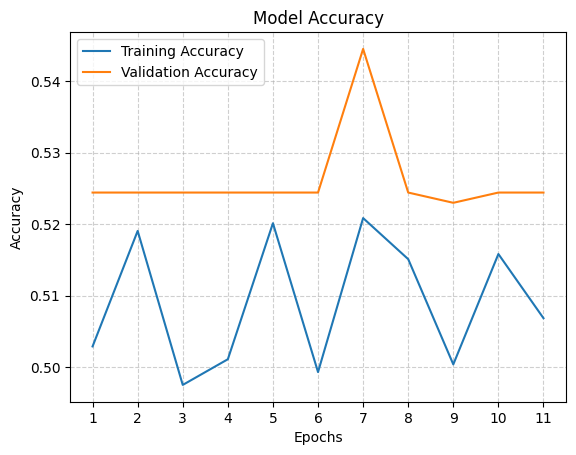

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_losses)+1)

# Loss Graph
plt.figure()
plt.plot(epochs_range, train_losses, label='Training Loss')
plt.plot(epochs_range, val_losses, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig("loss_graph.png")
plt.show()

# Accuracy Graph
plt.figure()
plt.plot(epochs_range, train_accuracies, label='Training Accuracy')
plt.plot(epochs_range, val_accuracies, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.xticks(epochs_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.savefig("accuracy_graph.png")
plt.show()

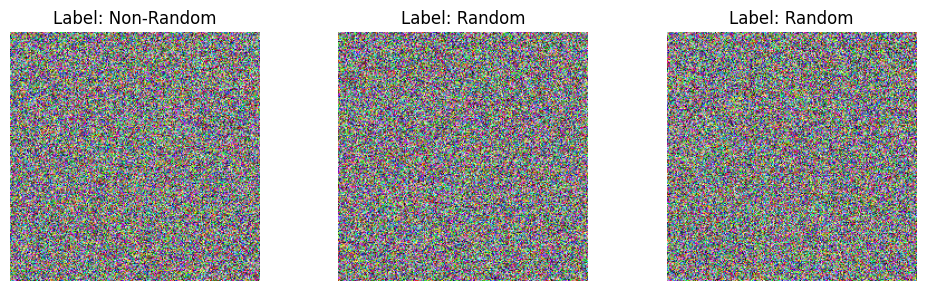

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.load('images_labels_rrr.npz')
images = data['images']
labels = data['labels']

# Pick indices (ensure mix of classes)
samples = []

# get 2 random + 1 non-random (adjust based on label mapping)
class_0_idx = np.where(labels == 0)[0]
class_1_idx = np.where(labels == 1)[0]

samples.append(class_0_idx[0])
samples.append(class_1_idx[0])
samples.append(class_1_idx[1])

# Plot
plt.figure(figsize=(10,3))

for i, idx in enumerate(samples):
    plt.subplot(1,3,i+1)
    plt.imshow(images[idx])
    plt.title(f"Label: {'Random' if labels[idx]==1 else 'Non-Random'}")
    plt.axis('off')

plt.tight_layout()
plt.show()